# Настройка окружения

In [3]:
!pip install facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 146.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 805.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [5]:
import os
os.chdir('/content')
CODE_DIR = 'interfacegan'
!git clone https://github.com/genforce/interfacegan.git $CODE_DIR
os.chdir(f'./{CODE_DIR}')
!wget https://www.dropbox.com/s/t74z87pk3cf8ny7/pggan_celebahq.pth?dl=1 -O models/pretrain/pggan_celebahq.pth --quiet
!wget https://www.dropbox.com/s/nmo2g3u0qt7x70m/stylegan_celebahq.pth?dl=1 -O models/pretrain/stylegan_celebahq.pth --quiet
!wget https://www.dropbox.com/s/qyv37eaobnow7fu/stylegan_ffhq.pth?dl=1 -O models/pretrain/stylegan_ffhq.pth --quiet

fatal: destination path 'interfacegan' already exists and is not an empty directory.


In [6]:
import os.path
import io
import IPython.display
import numpy as np
import cv2
import PIL.Image

import torch

from models.model_settings import MODEL_POOL
from models.pggan_generator import PGGANGenerator
from models.stylegan_generator import StyleGANGenerator
from utils.manipulator import linear_interpolate


def build_generator(model_name):
  """Builds the generator by model name."""
  gan_type = MODEL_POOL[model_name]['gan_type']
  if gan_type == 'pggan':
    generator = PGGANGenerator(model_name)
  elif gan_type == 'stylegan':
    generator = StyleGANGenerator(model_name)
  return generator


def sample_codes(generator, num, latent_space_type='Z', seed=0):
  """Samples latent codes randomly."""
  np.random.seed(seed)
  codes = generator.easy_sample(num)
  if generator.gan_type == 'stylegan' and latent_space_type == 'W':
    codes = torch.from_numpy(codes).type(torch.FloatTensor).to(generator.run_device)
    codes = generator.get_value(generator.model.mapping(codes))
  return codes


def imshow(images, col, viz_size=256):
  """Shows images in one figure."""
  num, height, width, channels = images.shape
  assert num % col == 0
  row = num // col

  fused_image = np.zeros((viz_size * row, viz_size * col, channels), dtype=np.uint8)

  for idx, image in enumerate(images):
    i, j = divmod(idx, col)
    y = i * viz_size
    x = j * viz_size
    if height != viz_size or width != viz_size:
      image = cv2.resize(image, (viz_size, viz_size))
    fused_image[y:y + viz_size, x:x + viz_size] = image

  fused_image = np.asarray(fused_image, dtype=np.uint8)
  data = io.BytesIO()
  PIL.Image.fromarray(fused_image).save(data, 'jpeg')
  im_data = data.getvalue()
  disp = IPython.display.display(IPython.display.Image(im_data))
  return disp

# Синтез аугментированных изображений лиц человека

In [7]:
model_name = "stylegan_ffhq"
latent_space_type = "Z"

generator = build_generator(model_name)

ATTRS = ['age', 'eyeglasses', 'gender', 'pose', 'smile']
boundaries = {}
for i, attr_name in enumerate(ATTRS):
  boundary_name = f'{model_name}_{attr_name}'
  if generator.gan_type == 'stylegan' and latent_space_type == 'W':
    boundaries[attr_name] = np.load(f'boundaries/{boundary_name}_w_boundary.npy')
  else:
    boundaries[attr_name] = np.load(f'boundaries/{boundary_name}_boundary.npy')

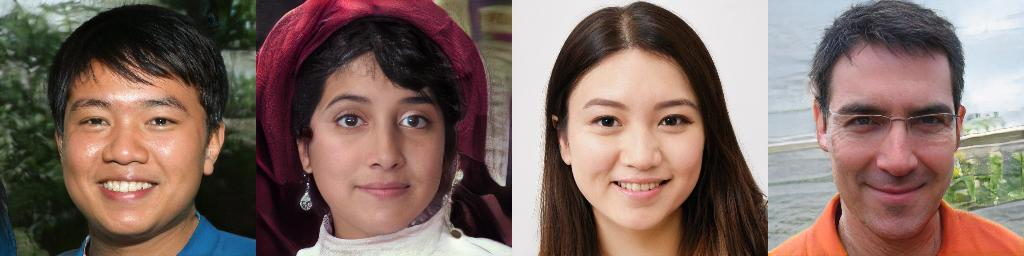

In [8]:
num_samples = 4
noise_seed = 91

latent_codes = sample_codes(generator, num_samples, latent_space_type, noise_seed)
if generator.gan_type == 'stylegan' and latent_space_type == 'W':
  synthesis_kwargs = {'latent_space_type': 'W'}
else:
  synthesis_kwargs = {}

images = generator.easy_synthesize(latent_codes, **synthesis_kwargs)['image']
imshow(images, col=num_samples)

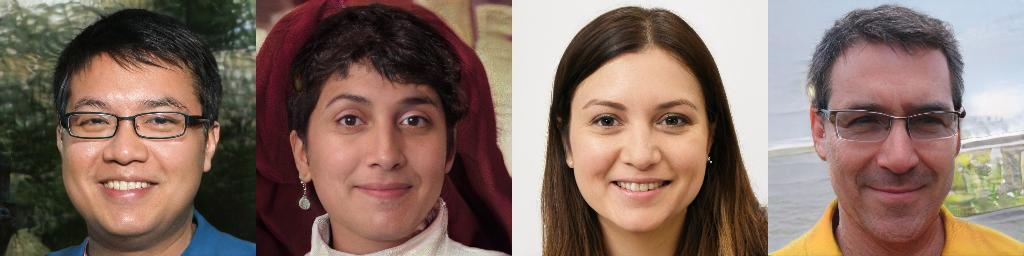

In [11]:
age = 1.1
eyeglasses = 0
gender = 0
pose = 0
smile = 0

new_codes = latent_codes.copy()
for i, attr_name in enumerate(ATTRS):
  new_codes += boundaries[attr_name] * eval(attr_name)

new_images = generator.easy_synthesize(new_codes, **synthesis_kwargs)['image']
imshow(new_images, col=num_samples)

# Детекция лица

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import cv2
from PIL import Image, ImageDraw
import torch
import facenet_pytorch
from facenet_pytorch import MTCNN, InceptionResnetV1
from IPython import display
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
plt.rcParams.update({'figure.figsize': (6, 6)})


In [7]:
mtcnn = MTCNN(keep_all=True, margin=30)
dir_path = '/content/drive/MyDrive/Курсовой_проект'

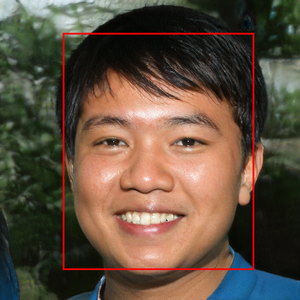

In [16]:
frame = Image.fromarray(images[0])
boxes, b = mtcnn.detect(frame)
box = boxes[0]
# edit boxes
box[0] -= 40
box[2] += 40
box[1] -= 100

frame_draw = frame.copy()
draw = ImageDraw.Draw(frame_draw)
draw.rectangle(box.tolist(), outline=(255, 0, 0), width=6)
frame_draw = frame_draw.resize((300, 300), Image.Resampling.LANCZOS)
display.display(frame_draw)

In [18]:
dir_path = '/content/drive/MyDrive/Курсовой_проект'
frame.save(f'{dir_path}/photo_original.jpeg')
with open(f'{dir_path}/box_photo_original.txt', 'w') as f:
    f.write(','.join(map(str, box)))

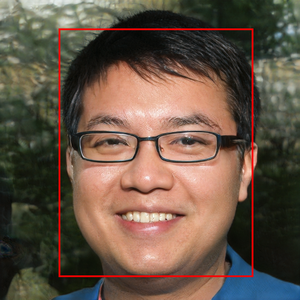

In [19]:
frame = Image.fromarray(new_images[0])
boxes, b = mtcnn.detect(frame)
box = boxes[0]
# edit boxes
box[0] -= 40
box[2] += 40
box[1] -= 100
frame_draw = frame.copy()
draw = ImageDraw.Draw(frame_draw)
draw.rectangle(box.tolist(), outline=(255, 0, 0), width=6)
frame_draw = frame_draw.resize((300, 300), Image.Resampling.LANCZOS)
display.display(frame_draw)

In [20]:
frame.save(f'{dir_path}/photo_older.jpeg')
with open(f'{dir_path}/box_photo_older.txt', 'w') as f:
    f.write(','.join(map(str, box)))

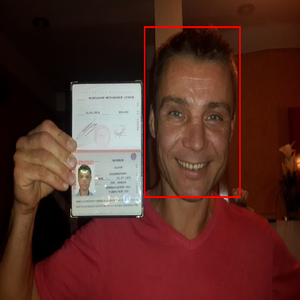

In [5]:
frame = Image.open('/content/drive/MyDrive/Курсовой_проект/selfie.jpeg')
boxes, b = mtcnn.detect(frame)
box = boxes[0]
# edit boxes
box[0] -= 40
box[2] += 40
box[1] -= 100
frame_draw = frame.copy()
draw = ImageDraw.Draw(frame_draw)
draw.rectangle(box.tolist(), outline=(255, 0, 0), width=6)
frame_draw = frame_draw.resize((300, 300), Image.Resampling.LANCZOS)
display.display(frame_draw)

In [8]:
with open(f'{dir_path}/box_selfie.txt', 'w') as f:
    f.write(','.join(map(str, box)))

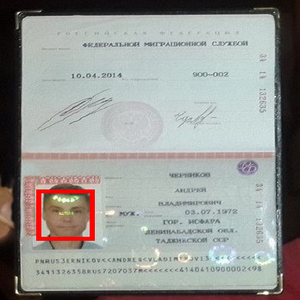

In [20]:
frame = Image.open('/content/drive/MyDrive/Курсовой_проект/document.jpeg')
boxes, b = mtcnn.detect(frame)
box = boxes[0]
# edit boxes
box[0] -= 10
box[1] -= 10
box[2] += 10
box[3] += 10
frame_draw = frame.copy()
draw = ImageDraw.Draw(frame_draw)
draw.rectangle(box.tolist(), outline=(255, 0, 0), width=6)
frame_draw = frame_draw.resize((300, 300), Image.Resampling.LANCZOS)
display.display(frame_draw)

In [21]:
with open(f'{dir_path}/box_document.txt', 'w') as f:
    f.write(','.join(map(str, box)))